# 06 - Initial LUX analysis

In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns


import ambient_light_epilepsy.nhanes as nhn
import ambient_light_epilepsy.cohort as ch
import ambient_light_epilepsy.lux_metrics as lm
import time

In [10]:
def plot_group_scatter(df_control, df_pwe, column, ylabel):
    """
    Creates a two-group jittered scatter plot with group means.

    Parameters
    ----------
    df_control : DataFrame
    df_pwe : DataFrame
    column : str
        Column name to plot
    ylabel : str
        Label for y-axis
    """

    control_vals = df_control[column].dropna()
    pwe_vals = df_pwe[column].dropna()

    fig, ax = plt.subplots(figsize=(3, 3))

    # Jitter
    jitter_strength = 0.08
    x_control = np.random.normal(0, jitter_strength, size=len(control_vals))
    x_pwe = np.random.normal(1, jitter_strength, size=len(pwe_vals))

    ax.scatter(x_control, control_vals, alpha=0.6)
    ax.scatter(x_pwe, pwe_vals, alpha=0.6)

    # Plot group means
    ax.scatter(0, control_vals.mean(), s=150, marker="_")
    ax.scatter(1, pwe_vals.mean(), s=150, marker="_")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Controls", "PWE"])
    ax.set_ylabel(ylabel)
    ax.set_title(column)

    plt.tight_layout()
    plt.show()



def cohens_d_value(group1, group2):
    
    mean1 = np.mean(group1)
    mean2 = np.mean(group2)
    
    sd1 = np.std(group1, ddof=1)
    sd2 = np.std(group2, ddof=1)
    
    n1 = len(group1)
    n2 = len(group2)
    
    # pooled SD
    sd_pooled = np.sqrt(
        ((n1 - 1)*sd1**2 + (n2 - 1)*sd2**2) / (n1 + n2 - 2)
    )
    
    return (mean1 - mean2) / sd_pooled

def plot_lux_distribution(df, x_col="epilepsy", y_col="mean_daytime_lux", transform='log', ax=None, figsize=(5, 3)):
    """
    function to plot a violin plot to compare *y_col* over different *x_col* (epilepsy status) 
    """

    if ax == None:
        fig, ax = plt.subplots(figsize=figsize)
    
    # Optional: Transform data to log scale if specified, matches your OLS model
    plot_data = df.copy()
    if transform=='log':
        plot_data[y_col] = np.log1p(plot_data[y_col])
        ylabel = f"Log({y_col} + 1)"
    elif transform=='sqrt':
        plot_data[y_col] = np.sqrt(plot_data[y_col])
        ylabel = f"sqrt({y_col})"
    else:
        ylabel = y_col

    # Create the violin plot
    sns.violinplot(
        data=plot_data, 
        x=x_col, 
        y=y_col, 
        inner="box",      # Draws a mini boxplot inside the violin
        palette="muted", 
        hue=x_col,
        cut=0,             # Limits the violin to the actual data range
        ax=ax
    )
    
    plt.title(f"{y_col} ({transform})")
    ax.set_xlabel("Group (0=Control, 1=Epilepsy)")
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)

    return ax

## Run/load analysis

In [12]:
# =============================================================================
# Run analysis
# =============================================================================


# base_path = "W:/projects/ambient_light_epilepsy_analysis/data"

# # Run analysis for G cohort 
# control_seqn, pwe_seqn = ch.load_freq_matched_control_groups("G")
# df_control_summary_G = compute_lux_summary(control_seqn, "G", base_path)
# df_pwe_summary_G     = compute_lux_summary(pwe_seqn, "G", base_path)

# # Save results
# df_control_summary_G.to_csv(f"C:/Users/ahernj/Documents/Projects/ambient_light_epilepsy_analysis/analysis/control_lux_summary_G.csv")
# df_pwe_summary_G.to_csv(f"C:/Users/ahernj/Documents/Projects/ambient_light_epilepsy_analysis/analysis/pwe_lux_summary_G.csv")

# # Run analysis for H cohort 
# control_seqn, pwe_seqn = ch.load_freq_matched_control_groups("H")
# df_control_summary_H = compute_lux_summary(control_seqn, "H", base_path)
# df_pwe_summary_H     = compute_lux_summary(pwe_seqn, "H", base_path)

# # Save results
# df_control_summary_H.to_csv(f"C:/Users/ahernj/Documents/Projects/ambient_light_epilepsy_analysis/analysis/control_lux_summary_H.csv")
# df_pwe_summary_H.to_csv(f"C:/Users/ahernj/Documents/Projects/ambient_light_epilepsy_analysis/analysis/pwe_lux_summary_H.csv")

In [13]:
# # =============================================================================
# # Run analysis
# # =============================================================================


# # Load both summary tables for each cohort 
# year = "G"
# df_control_summary_G = pd.read_csv(f"C:/Users/ahernj/Documents/Projects/ambient_light_epilepsy_analysis/analysis/control_lux_summary_G.csv")
# df_pwe_summary_G = pd.read_csv(f"C:/Users/ahernj/Documents/Projects/ambient_light_epilepsy_analysis/analysis/pwe_lux_summary_G.csv")

# year = "H"
# df_control_summary_H = pd.read_csv(f"C:/Users/ahernj/Documents/Projects/ambient_light_epilepsy_analysis/analysis/control_lux_summary_H.csv")
# df_pwe_summary_H = pd.read_csv(f"C:/Users/ahernj/Documents/Projects/ambient_light_epilepsy_analysis/analysis/pwe_lux_summary_H.csv")



# # Add cohort and epilepsy labels before merging
# def add_labels(df, cohort_label, epilepsy_status):
#     df = df.copy()
#     df["cohort"] = cohort_label
#     df["epilepsy"] = epilepsy_status  # 1 = PWE, 0 = control
#     return df
    
# df_G_pwe = add_labels(df_pwe_summary_G, "G", 1)
# df_G_ctrl = add_labels(df_control_summary_G, "G", 0)

# df_H_pwe = add_labels(df_pwe_summary_H, "H", 1)
# df_H_ctrl = add_labels(df_control_summary_H, "H", 0)

# # Merge all 
# df_all = pd.concat(
#     [df_G_pwe, df_G_ctrl, df_H_pwe, df_H_ctrl],
#     ignore_index=True
# )

# # Add employment and depression status to summary table 
# df_all = nhn.add_employment_and_depression_status(df_all)

# # Add demographic data 
# df_all = nhn.add_demographic_data(df_all)

# # Add outdoor time data
# df_all = nhn.add_outdoor_time(df_all)

# # Save the analysis results as a CSV file
# df_all.to_csv(f"C:/Users/ahernj/Documents/Projects/ambient_light_epilepsy_analysis/analysis/lux_5min_fmatch_analysis.csv")

In [14]:
# =============================================================================
# Load analysis
# =============================================================================

p = "W:/projects/ambient_light_epilepsy_analysis/analysis/lux/lux_5min_fmatch_analysis.csv"
df_all = pd.read_csv(p, index_col=0)
df_all

,SEQN,timezone,duration_hours,mean_lux,mean_daytime_lux,mean_nighttime_lux,time_above_threshold,M10,L5,RA,...,employed,depressed,age,sex,race,a_ed,PIR,NIH,season,minutes_outdoors
0,62218.0,UTC,222.166667,133.016037,242.679336,19.242723,68.571429,283.219554,2.546784,0.982176,...,0,0.0,38.0,2.0,4.0,4.0,4.05,3.0,1.0,0.0
1,62282.0,UTC,192.083333,20.843251,40.438316,0.953299,7.493495,46.339642,0.003403,0.999853,...,1,0.0,57.0,2.0,4.0,5.0,1.70,2.0,1.0,30.0
2,62293.0,UTC,192.083333,18.989081,36.077126,1.818291,8.742411,42.688042,1.205729,0.945061,...,0,NaN,67.0,1.0,3.0,4.0,1.16,1.0,2.0,NaN
3,62307.0,UTC,192.083333,44.976663,80.318809,4.919599,24.353859,98.262948,1.641486,0.967139,...,0,0.0,61.0,1.0,4.0,3.0,1.20,2.0,2.0,NaN
4,62370.0,UTC,192.083333,62.269247,117.559670,1.761620,27.476149,147.080298,0.000000,1.000000,...,0,0.0,21.0,1.0,6.0,4.0,3.70,5.0,2.0,90.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,81103.0,UTC,192.083333,122.073670,241.802721,0.923383,66.816999,287.891632,0.397111,0.997245,...,0,0.0,80.0,1.0,4.0,3.0,2.67,2.0,1.0,NaN
857,81997.0,UTC,192.083333,184.755259,354.008004,10.198465,99.913270,417.019819,0.200632,0.999038,...,0,0.0,80.0,1.0,3.0,4.0,1.02,4.0,1.0,NaN
858,78899.0,UTC,192.083333,49.309750,98.002270,0.595559,27.476149,116.824593,0.000000,1.000000,...,0,0.0,80.0,1.0,3.0,5.0,2.78,3.0,1.0,NaN
859,76531.0,UTC,192.083333,20.822221,39.905744,1.034286,4.995663,45.164121,0.245993,0.989166,...,0,0.0,80.0,1.0,3.0,1.0,1.91,4.0,1.0,NaN


## Compare light metrics

In [15]:
def compare_distributions(df1, df2, label1="Controls", label2="PWE", column="mean_daytime_lux"):
    # Calculate describe for both and combine into one DataFrame
    comparison_df = pd.DataFrame({
        label1: df1[column].describe(),
        label2: df2[column].describe()
    })

    # Add median row 
    comparison_df.loc["median"] = [df1[column].median(), df2[column].median()]
    
    print(f"=== {column} Comparison ===")
    print(comparison_df)
    print()

# Define summary tables (combined beteen cohorts)
df_pwe_summary = df_all[df_all['epilepsy']==1]
df_control_summary = df_all[df_all['epilepsy']==0]

# Print descriptions of measuremnt distribtions
compare_distributions(df_control_summary, df_pwe_summary, column="mean_daytime_lux")
compare_distributions(df_control_summary, df_pwe_summary, column="mean_nighttime_lux")
compare_distributions(df_control_summary, df_pwe_summary, column="time_above_threshold")
compare_distributions(df_control_summary, df_pwe_summary, column="M10")
compare_distributions(df_control_summary, df_pwe_summary, column="L5")
compare_distributions(df_control_summary, df_pwe_summary, column="RA")
compare_distributions(df_control_summary, df_pwe_summary, column="m10_midpoint")
compare_distributions(df_control_summary, df_pwe_summary, column="l5_midpoint")
compare_distributions(df_control_summary, df_pwe_summary, column="IS")
compare_distributions(df_control_summary, df_pwe_summary, column="IV")

=== mean_daytime_lux Comparison ===
           Controls         PWE
count    669.000000  192.000000
mean     217.296609  170.323989
std      172.514337  135.147955
min        0.000000    1.306196
25%       92.706262   69.390610
50%      174.124809  135.007512
75%      300.149164  240.752253
max     1278.921097  682.232289
median   174.124809  135.007512

=== mean_nighttime_lux Comparison ===
          Controls         PWE
count   669.000000  192.000000
mean      7.572123    7.014556
std      13.605985   10.682189
min       0.000000    0.001578
25%       1.307785    1.102469
50%       3.801535    3.003198
75%       9.028927    8.334083
max     188.544248   70.069032
median    3.801535    3.003198

=== time_above_threshold Comparison ===
          Controls         PWE
count   669.000000  192.000000
mean     60.777322   46.002127
std      57.907370   45.380825
min       0.000000    0.000000
25%      18.109280   11.708586
50%      44.336513   33.408500
75%      87.424111   64.006938
max   

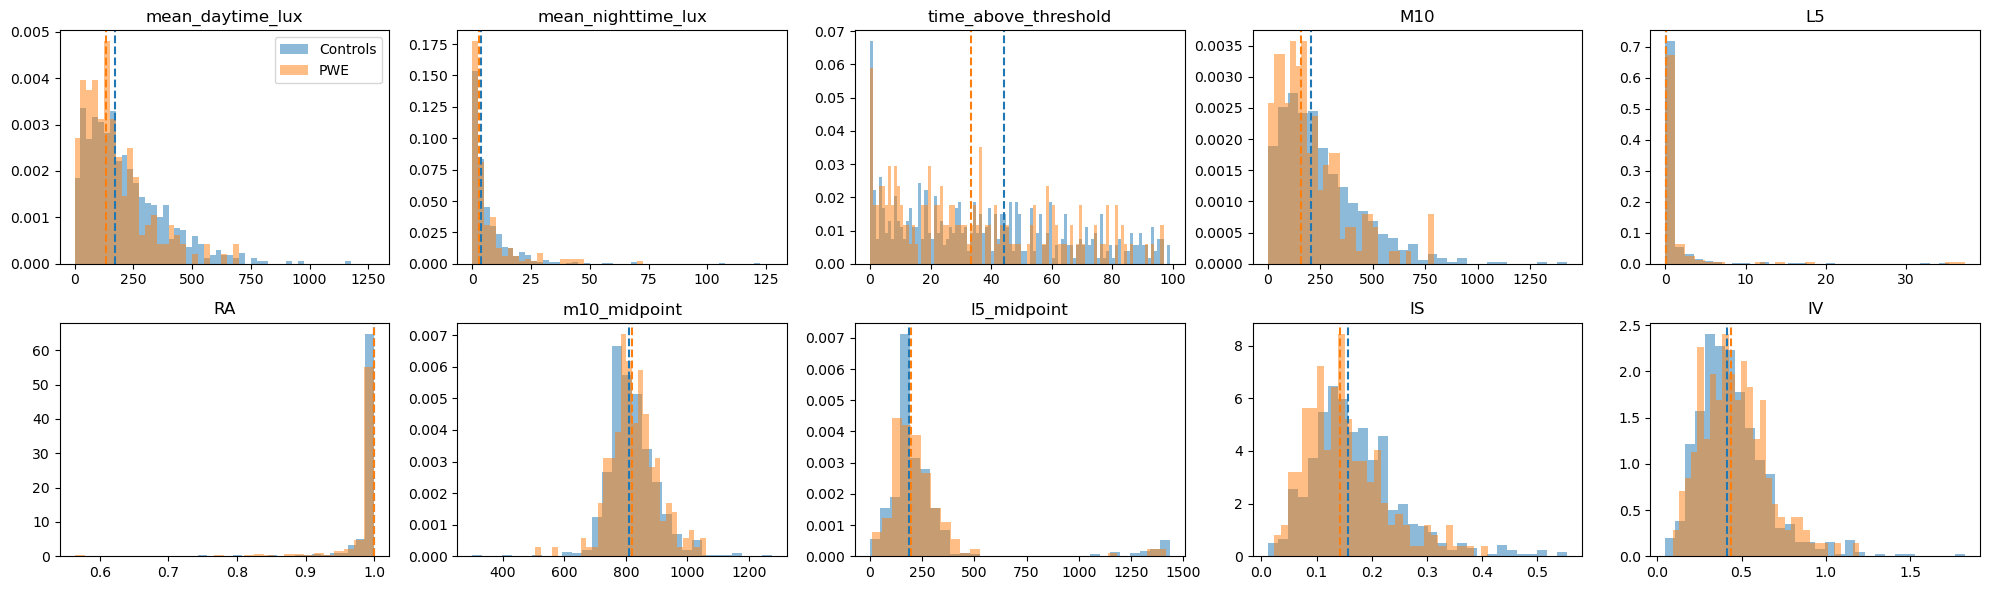

In [16]:
value_bins = {
    "mean_daytime_lux": np.arange(0, 1300, 25),
    "mean_nighttime_lux": np.arange(0, 130, 2.5),
    "time_above_threshold": np.arange(0, 100, 1),
    "M10": 30,
    "L5": 30,
    "RA": 30,
    "m10_midpoint": 30,
    "l5_midpoint": 30,
    "IS": 30,
    "IV": 30
}

fig, Ax = plt.subplots(2, 5, figsize=(20, 6), tight_layout=True)
Ax = Ax.reshape(-1)

for i, value in enumerate(value_bins.keys()):
    ax = Ax[i]
    ax.hist(df_control_summary[value], alpha=0.5, label="Controls", density=True, bins=value_bins[value])
    ax.hist(df_pwe_summary[value], alpha=0.5, label="PWE", density=True, bins=value_bins[value])
    ax.axvline(df_control_summary[value].median(), color='C0', ls='--')
    ax.axvline(df_pwe_summary[value].median(), color='C1', ls='--')
    ax.set_title(value)

    if i ==0:
        ax.legend()

plt.show()

## Statistics

Simple stats test can be used to understand whether there are statistical differneces between the distributions of the metrics:
- Mann–Whitney U test: no distribution assumption, it just requires independent smaples and continuous values.
- Welch t-test: assumes normal distribution or large sample size. Tests the null hypothesis that two samples have the same average.
- Welch t-test on `np.log(lux + 1)`: this transforms data to more normal.

Next a GLM is used to take into account confounding factors. This model asks "Is epilepsy associated with this `metric` after controlling for age, sex, PIR, education, season and cohort? Both GLM and simple tests converge (for the 5min sampled data) and indicate that there are significant differneces between PWE and controls for the following LUX metrics:
- `mean_daytime_lux`, lower for PWE
- `time_above_threshold`, lower for PWE, threshold=1000
- `m10`, lower for PWE
- `IS`, interdaily stability, lower for PWE (less regular day-to-day rhythm)

It is reasonable to assume that these differences in light exposure patterns could be due to employment status or depression. Inclusing these factors both separatly and together in a GLM indicates that they both explain some of the differences in exposure to light, but the effect of epilepsy remains significant after adjusting for both. For IS, after adjusting for emplyment and depression, epilepsy is no longer a statistically significant predictor of IS. 

In [17]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, ttest_ind
from statsmodels.stats.multitest import multipletests

import statsmodels.formula.api as smf
from scipy.stats import shapiro
from statsmodels.stats.multitest import multipletests



metrics = [
    "mean_daytime_lux",
    "mean_nighttime_lux",
    "time_above_threshold",
    "M10",
    "L5",
    "RA",
    "m10_midpoint",
    "l5_midpoint",
    "IS",
    "IV"
]

results = []

for metric in metrics:

    # Extract groups
    control = df_all[df_all["epilepsy"] == 0][metric].dropna()
    pwe     = df_all[df_all["epilepsy"] == 1][metric].dropna()

    # Mann–Whitney
    u_stat, p_mwu = mannwhitneyu(control, pwe, alternative="two-sided")

    # log transform (safe version)
    control_log = np.log(control + 1)
    pwe_log = np.log(pwe + 1)

    # Welch t-test - need normal distributions or large sample sizes here
    # on raw lux
    t_stat, p_ttest = ttest_ind(control, pwe, equal_var=False)
    # on log(lux+1)
    t_stat_log, p_ttest_log = ttest_ind(control_log, pwe_log, equal_var=False)

    results.append({
        "metric": metric,
        "n_control": len(control),
        "n_pwe": len(pwe),
        "MWU_p": p_mwu,
        "Welch_p": p_ttest,
        "Welch_log_p": p_ttest_log
    })

results_df = pd.DataFrame(results)

# Correct p-values for multiple comparions
results_df["MWU_FDR"] = multipletests(results_df["MWU_p"], method="fdr_bh")[1]
results_df["Welch_FDR"] = multipletests(results_df["Welch_p"], method="fdr_bh")[1]
results_df["Welch_log_FDR"] = multipletests(results_df["Welch_log_p"], method="fdr_bh")[1]

# Determine a *strict* condition for significance
results_df['significant'] = (results_df["MWU_FDR"]<0.05) & (results_df["Welch_FDR"]<0.05) & (results_df["Welch_log_FDR"]<0.05)

results_df

,metric,n_control,n_pwe,MWU_p,Welch_p,Welch_log_p,MWU_FDR,Welch_FDR,Welch_log_FDR,significant
0,mean_daytime_lux,669,192,0.000683,0.000084,0.003593,0.004537,0.000838,0.017964,True
1,mean_nighttime_lux,669,192,0.137221,0.550577,0.229209,0.218609,0.550577,0.327442,False
2,time_above_threshold,669,192,0.001694,0.000225,0.009839,0.004537,0.000940,0.024597,True
3,M10,669,192,0.001168,0.000282,0.005501,0.004537,0.000940,0.018336,True
4,L5,669,192,0.706312,0.384167,0.386597,0.706312,0.480209,0.429552,False
5,RA,668,192,0.335164,0.070567,0.076312,0.372404,0.141135,0.152624,False
6,m10_midpoint,669,192,0.055272,0.151498,0.150342,0.110543,0.252497,0.250569,False
7,l5_midpoint,669,192,0.174359,0.289761,0.720219,0.218609,0.413944,0.720219,False
8,IS,668,192,0.001815,0.001892,0.001970,0.004537,0.004730,0.017964,True
9,IV,668,192,0.174887,0.462479,0.369705,0.218609,0.513865,0.429552,False


In [21]:
df_all

,SEQN,timezone,duration_hours,mean_lux,mean_daytime_lux,mean_nighttime_lux,time_above_threshold,M10,L5,RA,...,employed,depressed,age,sex,race,a_ed,PIR,NIH,season,minutes_outdoors
0,62218.0,UTC,222.166667,133.016037,242.679336,19.242723,68.571429,283.219554,2.546784,0.982176,...,0,0.0,38.0,2.0,4.0,4.0,4.05,3.0,1.0,0.0
1,62282.0,UTC,192.083333,20.843251,40.438316,0.953299,7.493495,46.339642,0.003403,0.999853,...,1,0.0,57.0,2.0,4.0,5.0,1.70,2.0,1.0,30.0
2,62293.0,UTC,192.083333,18.989081,36.077126,1.818291,8.742411,42.688042,1.205729,0.945061,...,0,NaN,67.0,1.0,3.0,4.0,1.16,1.0,2.0,NaN
3,62307.0,UTC,192.083333,44.976663,80.318809,4.919599,24.353859,98.262948,1.641486,0.967139,...,0,0.0,61.0,1.0,4.0,3.0,1.20,2.0,2.0,NaN
4,62370.0,UTC,192.083333,62.269247,117.559670,1.761620,27.476149,147.080298,0.000000,1.000000,...,0,0.0,21.0,1.0,6.0,4.0,3.70,5.0,2.0,90.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,81103.0,UTC,192.083333,122.073670,241.802721,0.923383,66.816999,287.891632,0.397111,0.997245,...,0,0.0,80.0,1.0,4.0,3.0,2.67,2.0,1.0,NaN
857,81997.0,UTC,192.083333,184.755259,354.008004,10.198465,99.913270,417.019819,0.200632,0.999038,...,0,0.0,80.0,1.0,3.0,4.0,1.02,4.0,1.0,NaN
858,78899.0,UTC,192.083333,49.309750,98.002270,0.595559,27.476149,116.824593,0.000000,1.000000,...,0,0.0,80.0,1.0,3.0,5.0,2.78,3.0,1.0,NaN
859,76531.0,UTC,192.083333,20.822221,39.905744,1.034286,4.995663,45.164121,0.245993,0.989166,...,0,0.0,80.0,1.0,3.0,1.0,1.91,4.0,1.0,NaN


In [9]:
def choose_transform(series):

    series = series.dropna()

    candidates = {
        "none": series,
        "log": np.log(series + 1),
        "sqrt": np.sqrt(series)
    }

    best = None
    best_p = -1

    for name, s in candidates.items():

        if len(s) > 5000:
            s = s.sample(5000)

        p = shapiro(s)[1]

        if p > best_p:
            best_p = p
            best = name

    return best

    

def run_adjusted_model(df, metric):

    transform = choose_transform(df[metric])

    if transform == "log":
        formula = f"np.log({metric} + 1) ~ epilepsy + age + sex + PIR + a_ed + season + cohort"

    elif transform == "sqrt":
        formula = f"np.sqrt({metric}) ~ epilepsy + age + sex + PIR + a_ed + season + cohort"

    else:
        formula = f"{metric} ~ epilepsy + age + sex + PIR + a_ed + season + cohort"

    model = smf.ols(formula, data=df).fit(cov_type="HC3")

    coef = model.params["epilepsy"]
    p = model.pvalues["epilepsy"] 

    return {
        "metric": metric,
        "transform": transform,
        "coef": coef,
        "p_value": p,
        "model": model
    }

metrics = [
    "mean_daytime_lux",
    "mean_nighttime_lux",
    "time_above_threshold",
    "M10",
    "L5",
    "RA",
    "m10_midpoint",
    "l5_midpoint",
    "IS",
    "IV"
]


# Run the GLM for every metric 
results = []
for m in metrics:
    res = run_adjusted_model(df_all, m)
    results.append(res)

results_df = pd.DataFrame(results)


# Correct p-values for multiple comparisons
results_df["p_corrected"] = multipletests(results_df["p_value"],method="fdr_bh")[1]

# print(results_df.loc[1].model.summary())

display(results_df)

,metric,transform,coef,p_value,model,p_corrected
0,mean_daytime_lux,sqrt,-1.499598,0.000364,<statsmodels.regression.linear_model.Regressio...,0.003059
1,mean_nighttime_lux,log,-0.105027,0.194857,<statsmodels.regression.linear_model.Regressio...,0.278368
2,time_above_threshold,sqrt,-0.890649,0.000918,<statsmodels.regression.linear_model.Regressio...,0.003059
3,M10,sqrt,-1.523172,0.000800,<statsmodels.regression.linear_model.Regressio...,0.003059
4,L5,sqrt,0.050219,0.480674,<statsmodels.regression.linear_model.Regressio...,0.536953
5,RA,none,-0.006190,0.085234,<statsmodels.regression.linear_model.Regressio...,0.170467
6,m10_midpoint,none,9.073853,0.157583,<statsmodels.regression.linear_model.Regressio...,0.262638
7,l5_midpoint,log,0.016811,0.748467,<statsmodels.regression.linear_model.Regressio...,0.748467
8,IS,sqrt,-0.022157,0.004113,<statsmodels.regression.linear_model.Regressio...,0.010281
9,IV,sqrt,0.008182,0.483258,<statsmodels.regression.linear_model.Regressio...,0.536953


### Employment and depression

In [10]:
results_dict = {}


# Find the number of people from each group that have missing depression status
nan_depressed = df_all[df_all["depressed"].isna()]
num_nan_dep_ep = (nan_depressed["epilepsy"]==1).sum()
num_nan_dep_cntl = (nan_depressed["epilepsy"]==0).sum()
print(f"Number of PWE with missing depression status: {num_nan_dep_ep}") # = 18 
print(f"Number of controls with missing depression status: {num_nan_dep_cntl}") # = 61

# Drop subjects without depression status from the following model to exclude any selection bias 
df_subset = df_all.dropna(subset=['depressed'])

for metric in ["mean_daytime_lux", "time_above_threshold", "M10", "IS"]:
    # Run the baseline model 
    model_0 = smf.ols(
        f"np.sqrt({metric}) ~ epilepsy + age + sex + PIR + a_ed + season + cohort",
        data=df_subset
    ).fit(cov_type='HC3')
    
    # Get the epilepsy parameters
    model_0_pars = {"coef": model_0.params["epilepsy"], "p": model_0.pvalues["epilepsy"]}
    
    
    # Run the employment model 
    model_1 = smf.ols(
        f"np.sqrt({metric}) ~ epilepsy + age + sex + PIR + a_ed + season + cohort + employed",
        data=df_subset
    ).fit(cov_type='HC3')
    
    model_1_pars = {"coef": model_1.params["epilepsy"], "p": model_1.pvalues["epilepsy"]}
    
    
    # Run the depression model 
    model_2 = smf.ols(
        f"np.sqrt({metric}) ~ epilepsy + age + sex + PIR + a_ed + season + cohort + depressed",
        data=df_subset
    ).fit(cov_type='HC3')
    
    model_2_pars = {"coef": model_2.params["epilepsy"], "p": model_2.pvalues["epilepsy"]}
    
    
    # Run the ful employment + depression model 
    model_3 = smf.ols(
        f"np.sqrt({metric}) ~ epilepsy + age + sex + PIR + a_ed + season + cohort + employed + depressed",
        data=df_subset
    ).fit(cov_type='HC3')
    
    model_3_pars = {"coef": model_3.params["epilepsy"], "p": model_3.pvalues["epilepsy"]}
    
    # Combine results into a dataframe
    metric_results = pd.DataFrame([model_0_pars, model_1_pars, model_2_pars, model_3_pars],
                                   index=["Baseline", "Employment", "Depression", "Full"])


    # Add to dictionary with the metric name as the key
    results_dict[metric] = metric_results


# Concatenate along axis 1 to create the hierarchical columns
final_df = pd.concat(results_dict, axis=1)
display(final_df)

Number of PWE with missing depression status: 18
Number of controls with missing depression status: 61


mean_daytime_lux           time_above_threshold            \
                       coef         p                 coef         p   
Baseline          -1.418209  0.000958            -0.852257  0.001879   
Employment        -1.247283  0.006513            -0.773386  0.008504   
Depression        -1.330964  0.002533            -0.805286  0.004202   
Full              -1.195775  0.010153            -0.744302  0.012512   

                 M10                  IS            
                coef         p      coef         p  
Baseline   -1.426813  0.002083 -0.018732  0.018123  
Employment -1.276328  0.009991 -0.016641  0.047643  
Depression -1.339507  0.004915 -0.017414  0.034123  
Full       -1.222669  0.015070 -0.015812  0.065682

### Time outdoors

- Very surprsingly, time outdoors does not correlate with `mean_daytime_lux`
- Time outdoors does reduce the effect of epilepsy on LUX metrics, but only partially and the effect of epielpsy is still significant after accounting for time outdoors 

In [21]:
results_dict = {}

# Drop subjects without mins outdoors value from the following model to exclude any selection bias 
df_subset = df_all.dropna(subset=['minutes_outdoors'])

for metric in ["mean_daytime_lux", "time_above_threshold", "M10", "IS"]:
    # Run the baseline model 
    model_0 = smf.ols(
        f"np.sqrt({metric}) ~ epilepsy + age + sex + PIR + a_ed + season + cohort",
        data=df_subset
    ).fit(cov_type='HC3')

    
    # Get the epilepsy parameters
    model_0_pars = {"coef": model_0.params["epilepsy"], "p": model_0.pvalues["epilepsy"]}
    
    
    # Run the mins outdoors model 
    model_1 = smf.ols(
        f"np.sqrt({metric}) ~ epilepsy + age + sex + PIR + a_ed + season + cohort + minutes_outdoors",
        data=df_subset
    ).fit(cov_type='HC3')

    
    model_1_pars = {"coef": model_1.params["epilepsy"], "p": model_1.pvalues["epilepsy"]}

    # Combine results into a dataframe
    metric_results = pd.DataFrame([model_0_pars, model_1_pars],
                                   index=["Baseline", "Outdoors"])


    # Add to dictionary with the metric name as the key
    results_dict[metric] = metric_results


# Concatenate along axis 1 to create the hierarchical columns
final_df = pd.concat(results_dict, axis=1)
display(final_df)

mean_daytime_lux           time_above_threshold                 M10  \
                     coef         p                 coef         p      coef   
Baseline        -1.477649  0.002689            -0.967291  0.002147 -1.498497   
Outdoors        -1.245013  0.011511            -0.813508  0.009677 -1.251636   

                          IS            
                 p      coef         p  
Baseline  0.004855 -0.020745  0.021837  
Outdoors  0.018551 -0.016597  0.068210

In [22]:
# metric = "mean_daytime_lux"

# # Run the baseline model 
# model_baseline = smf.ols(
#     f"np.sqrt({metric}) ~ epilepsy + age + sex + PIR + a_ed + season + cohort",
#     data=df_subset
# ).fit(cov_type='HC3')
# print(model_baseline.summary())
# print()

# # Run the mins outdoors model 
# model_od = smf.ols(
#     f"np.sqrt({metric}) ~ epilepsy + age + sex + PIR + a_ed + season + cohort + minutes_outdoors",
#     data=df_subset
# ).fit(cov_type='HC3')
# print(model_od.summary())

                  mean_daytime_lux  minutes_outdoors
mean_daytime_lux          1.000000          0.211374
minutes_outdoors          0.211374          1.000000


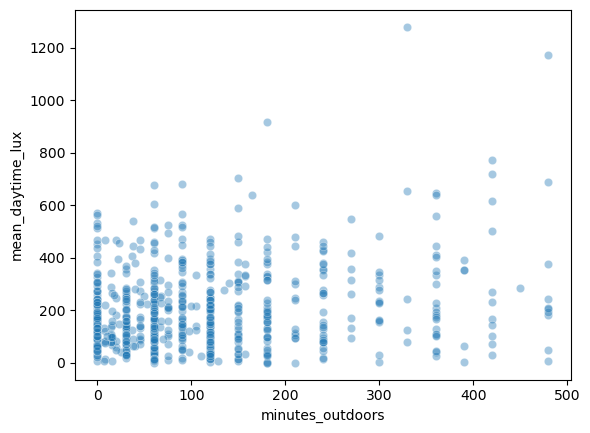

In [25]:
import seaborn as sns

# Print correlation analysis
print(df_subset[["mean_daytime_lux","minutes_outdoors"]].dropna().corr())


# Plot a scatter plot of time outdoors vs mean_daytime_lux
sns.scatterplot(
    data=df_subset,
    x="minutes_outdoors",
    y="mean_daytime_lux",
    alpha=0.4
)
plt.show()



{'n_control': 487,
 'n_pwe': 136,
 'MWU_p': np.float64(0.0003974406618134082),
 'Welch_p': np.float64(0.0011481071308729572),
 'Welch_log_p': np.float64(0.004431989048323532)}

<Axes: title={'center': 'minutes_outdoors (sqrt)'}, xlabel='Group (0=Control, 1=Epilepsy)', ylabel='sqrt(minutes_outdoors)'>

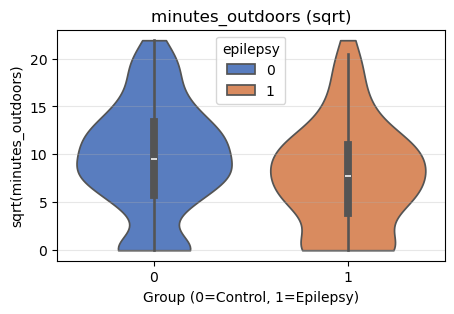

In [64]:
pwe = df_subset[df_subset['epilepsy']==1]['minutes_outdoors'].dropna()
control = df_subset[df_subset['epilepsy']==0]['minutes_outdoors'].dropna()

# Mann–Whitney
u_stat, p_mwu = mannwhitneyu(control, pwe, alternative="two-sided")

# log transform (safe version)
control_log = np.log(control + 1)
pwe_log = np.log(pwe + 1)

# Welch t-test - need normal distributions or large sample sizes here
# ... on raw lux
t_stat, p_ttest = ttest_ind(control, pwe, equal_var=False)
# .... on log(lux+1)
t_stat_log, p_ttest_log = ttest_ind(control_log, pwe_log, equal_var=False)

display({
"n_control": len(control),
"n_pwe": len(pwe),
"MWU_p": p_mwu,
"Welch_p": p_ttest,
"Welch_log_p": p_ttest_log
})


plot_lux_distribution(df_all, x_col="epilepsy", y_col="minutes_outdoors", transform='sqrt', ax=None, figsize=(5, 3))